# MACHINE LEARNING MODEL FOR APS5000 Remaining Useful Life (RUL) Prediction 

## 1- Required Libraries for the Analysis and file structures :
---
Required libraries listed within the file `requirements.txt`.
After the creation of a python virtual environment ([link_for_more_information](https://docs.python.org/3/library/venv.html)), to install all required libraries : execute `pip install requirements.txt -r` in the terminal.
File structure:
```
project/
|
├─.venv -> virtual environment
|
├─src/
|   ├─config.py
|   ├─ML_functions.py
|   ├─ML_utils.py
|   ├─model_wrapper.py
|   └─Stream_lit_functions.py
|
├─ML_coding_exercice.ipynb
├─requirements.txt
└─Streamlit_APS5000_Ageing_Monitoring.py
```
Specific library : PrediLib (PrediCare Python Library by Revima) -- *Please contact REVIMA PREDICARE Team for installation*
> **Important**
> For more details in this project, please refer to Jira Confluence article [Link](https://revima.atlassian.net/wiki/spaces/revhms/pages/edit-v2/150601730?draftShareId=1135fbc4-c765-412e-9a51-66d4fd405317)

In [8]:
#-------------------------------------------------------------------------
# Avoiding to restart everytime the Kernel
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
#-------------------------------------------------------------------------
# Importation des libraries nécessaires pour le projet
# ------------------------------------------------------------------------
from prediLib import JIRARequest,WILCORequest,get_apu_parameters_values
import pandas as pd
import numpy as np
import pickle
import os
from pathlib import Path
from datetime import datetime
import datetime
import json
import src.ML_utils as ML_utils
import src.config as config
from src.model_wrapper import ModelWrapper
import warnings
#------------------------- OBJECTS -------------------------------------------
from dataclasses import dataclass
from typing import Dict, Any, Tuple, List
#------------------------- PLOTTING LIBRARY ----------------------------------
import matplotlib.pyplot as plt
#------------------------- MACHINE LEARNING LIBRARY ---------------------------
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV,TimeSeriesSplit
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import clone

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay,
    brier_score_loss,make_scorer
)



from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier,RadiusNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.feature_selection import SelectKBest,mutual_info_classif
from lightgbm import LGBMClassifier

#------------------------- WARNINGS FILTERS ---------------------------
warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2- Jira, Wilco clients and data caching paths initialization:
---
This section will initialize jira and wilco clients. For credentials, *Please contact REVIMA PrediCare Team*.

Data caching path: this analysis required several parameters and query them each time is really time consuming. To avoid this, a data caching system is implemented. The user will wait for a some minutes for data querying for the first use of this notebook. Then, next time the scripts will use the cache.

***Important***
> After running this cell, a data_base folder will be created if it doesn't exist.


In [2]:
#-------------------------------------------------------------------------
# Initialisation des clients JIRA et WILCO pour faire les requetes des données
# ------------------------------------------------------------------------
jira_base_url=os.getenv("JIRA_REVIMA_BASE_URL")
jira_user=os.getenv("JIRA_USER")
jira_token=os.getenv("JIRA_API_TOKEN")
wilco_api_key=os.getenv("API_KEY")
jira_client=JIRARequest(base_url=jira_base_url,user_name=jira_user,user_token=jira_token)
wilco_client=WILCORequest(api_key=wilco_api_key)

#-------------------------------------------------------------------------
# chemins des dossiers pour le sauvegarde des bases de données et les
# ------------------------------------------------------------------------
raw_data_path=Path("data_base")/"raw_data_for_ML_analysis.pkl"
raw_data_checkpoint=Path("data_base")/"ml_data_checkpoint.json"
apuonwingsession_data_path=Path("data_base")/"on_wing_session.pkl"

raw_data_path.parent.mkdir(parents=True,exist_ok=True)

[ERROR] - Not able to connect to JIRA api 


## 3- Initializing needed Parameters from config file :
---

In [3]:
#-------------------------------------------------------------------------
# On récupère les parametres d'analyse depuis le fichier config.py
# ------------------------------------------------------------------------

AT_EVENT_parameters=config.AT_EVENT_parameters

MES_parameters=config.MES_parameters

All_parameters=AT_EVENT_parameters+MES_parameters

## 4- Data Query using PrediLib :
---

In [4]:
#-------------------------------------------------------------------------
# Requete des données de Wilco et JIRA
# Ce code permet de créer un dataframe nommé data_base qui contient les
# paramètres des APU.
# Après éxecution de cette cellule : un fichier pickle va être sauvegarder dans le dossier data_base. Ensuite, si une mise à jour de la base n'est pas nécessaire,
# cette cellule peut être ignoré.
# ------------------------------------------------------------------------
if os.path.exists(raw_data_path) and os.path.exists(raw_data_checkpoint):
    with open(raw_data_checkpoint,'r') as f:
        last_timestamp=json.load(f)
    existing_data_base=pd.read_pickle(raw_data_path)
    print(f"Number of rows of existing Database : {len(existing_data_base)}")
    try:
        data_base=get_apu_parameters_values(jira_client=jira_client,wilco_client=wilco_client,fwot_type="B787",parameters=All_parameters,current_data=True,from_date=last_timestamp['last_timestamp'])
        raw_data_counts=len(data_base)
        data_base=data_base.sort_values(by=['Reg','Date'],ascending=[False,True]).reset_index(drop=True)
        data_base[All_parameters]=data_base[All_parameters].map(ML_utils.converter_to_float)
        data_base[MES_parameters]=data_base.loc[:,MES_parameters].bfill()
        data_base.dropna(subset=AT_EVENT_parameters,how='all',inplace=True)
        print("[DONE] - Fetching Data From WILCO and Data cleaning")
        print("="*60)
        print(f"Number of Rows Cleaned data : {len(data_base)}")
        print(f"Percentage of data lost during Cleaning Process : {100-(100*round(len(data_base)/raw_data_counts,2))} %")
        print("="*60)
        new_data_base=pd.concat([existing_data_base,data_base],ignore_index=True)
        new_data_base.to_pickle(raw_data_path)
        print(f"Raw Database successfuly saved in  : {raw_data_path}")
        print("="*60)
        max_time=datetime.datetime.strftime(new_data_base.Date.max(),format="%Y-%m-%dT%H:%M:%S")
        with open(raw_data_checkpoint,'w') as f:
            json.dump({"last_timestamp":max_time},f,indent=4)
        print(f"Checkpoint successfuly saved in : {raw_data_checkpoint}")
    except Exception as e:
        print(f"[ERROR] during data extraction from JIRA and Wilco")
        print(f"{e}")
else:
    try:
        data_base=get_apu_parameters_values(jira_client=jira_client,wilco_client=wilco_client,fwot_type="B787",parameters=All_parameters,current_data=True,from_date="2020-01-01T00:00:00")
        raw_data_counts=len(data_base)
        data_base=data_base.sort_values(by=['Reg','Date'],ascending=[False,True]).reset_index(drop=True)
        data_base[All_parameters]=data_base[All_parameters].map(ML_utils.converter_to_float)
        data_base[MES_parameters]=data_base.loc[:,MES_parameters].bfill()
        data_base.dropna(subset=AT_EVENT_parameters,how='all',inplace=True)
        print("[DONE] - Fetching Data From WILCO and Data cleaning")
        print("="*60)
        print(f"Number of Rows Cleaned data : {len(data_base)}")
        print(f"Percentage of data lost during Cleaning Process : {100-(100*round(len(data_base)/raw_data_counts,2))} %")
        print("="*60)
    except Exception as e:
        print(f"[ERROR] during data extraction from JIRA and Wilco")
        print(f"{e}")
    data_base.to_pickle(raw_data_path)
    print(f"Raw Database successfuly saved in  : {raw_data_path}")
    print("="*60)
    max_time=datetime.datetime.strftime(data_base.Date.max(),format="%Y-%m-%dT%H:%M:%S")
    with open(raw_data_checkpoint,'w') as f:
        json.dump({"last_timestamp":max_time},f,indent=4)
    print(f"Checkpoint successfuly saved in : {raw_data_checkpoint}")

Number of rows of existing Database : 643569
JIRA API REQUEST
Found : 100 Issues - Page 0
Found : 100 Issues - Page 1
Found : 100 Issues - Page 2
Found : 47 Issues - Page 3
JIRA API REQUEST SUCCESSFUL
FIELD MAPPING
FIELD MAPPING SUCCESSFUL


Fetching Data from Wilco: 100%|██████████████████████████████| 347/347 [00:24<00:00, 14.12/s]



Unique fwot extracted from Jira : 128

Number of rows extracted from Wilco: 3318


Combining Jira data with Wilco samples: 100%|██████████████████████████████| 347/347 [00:00<00:00, 473.56fwot/s]


[DONE] - Fetching Data From WILCO and Data cleaning
Number of Rows Cleaned data : 1016
Percentage of data lost during Cleaning Process : 69.0 %
Raw Database successfuly saved in  : data_base\raw_data_for_ML_analysis.pkl
Checkpoint successfuly saved in : data_base\ml_data_checkpoint.json


In [4]:
# S'IL EXISTE DEJA DES DONNEES TELECHARGEES - CETTE CELLULE VA RECUPERER LES DONNEES EXISTANTE
#-------------------------------------------------------------------------
# Récupération des APU on Wing Session de JIRA afin d'identifier les
# déposes dans le passé pour les données d'entrainement du modèle ML
# ------------------------------------------------------------------------
if os.path.exists(apuonwingsession_data_path):
    df_jira=pd.read_pickle(apuonwingsession_data_path)
else:
    df_jira=pd.DataFrame(jira_client.get_onwing_sessions(fwot_type='B787',past_data=True,current_data=False))
    df_jira.to_pickle(apuonwingsession_data_path)
if os.path.exists(raw_data_path):
    data_base=pd.read_pickle(raw_data_path)
else:
    print(f"No files in {raw_data_path} - You have to run Section 3 of this notebook")

## 6- Data Preparation :
---
This section will cover all data cleaning, Preprocessing and data labeling strategy. It includes data normalization, handling missing values, engineering features computation and data partitioning for training and test samples.
> See Jira confluence documentation for more information [Link](https://revima.atlassian.net/wiki/spaces/revhms/pages/edit-v2/150601730?draftShareId=1135fbc4-c765-412e-9a51-66d4fd405317)

In [ ]:
#-------------------------------------------------------------------------
# Normalisation des parameters et séparation des données d'entrainement
# ------------------------------------------------------------------------
data_base_norm=ML_utils.compute_features(
    df_samples=data_base,
    rolling_configs=config.rolling_configs,
    rolling_values=config.ROLLING_VALUES,
    CUM_SUM_dict=config.CUM_SUM_cols,
    param_norm_dict=config.Parameters_max_scale_for_normalization)
removals_for_training_dataset=df_jira[(df_jira.Reason_for_removal.isin(['Performance deterioration']))].copy()
train_dataset=pd.DataFrame()
mask_egt_filtering=((data_base_norm['MES_EGT_CORRECTED']>(450/config.Parameters_max_scale_for_normalization['MES_EGT_CORRECTED'])) 
                    & (data_base_norm['TOTAL_GENLOAD']>=(150/config.Parameters_max_scale_for_normalization['TOTAL_GENLOAD']))
                    & (data_base_norm['MES_EGT_CORRECTED']<(640/config.Parameters_max_scale_for_normalization['MES_EGT_CORRECTED'])))
for _,item in removals_for_training_dataset.iterrows():
    fwot=item['Fwot']
    inst_date=item['Installation_date']
    rem_date=item['Removal_date']
    try:
        single_fwot=ML_utils.calculate_RUL(df=data_base_norm[mask_egt_filtering],reg=fwot,install_date=inst_date,removal_date=rem_date)
        if len(single_fwot)==0:
            print(f"{fwot},{inst_date},{rem_date} -> Skipped")
        else:
            print(f"{fwot},{inst_date},{rem_date} -> Added")
        train_dataset=pd.concat([train_dataset,single_fwot],ignore_index=True)
    except Exception as e:
        print(f"{fwot},{inst_date},{rem_date} -> Error here")
        continue
train_dataset=train_dataset.sort_values(by=["RUL_days","Reg"],ascending=[False,False]).reset_index(drop=True)
train_dataset,mapping_categories=ML_utils.add_threshold_classes(df=train_dataset,col='RUL_days',thresholds=[180,365],out_col='Category')

#---------------------------------- Separation des données d'entrainement et de Test---------------------------------------------------
classification_features=list(k for k in config.Parameters_max_scale_for_normalization.keys() if k in train_dataset.columns)+ML_utils.get_rolling_column_names(rolling_configs=config.rolling_configs,rolling_values=config.ROLLING_VALUES)
X_test,Y_test,X_train,Y_train=ML_utils.time_series_split(
    train_dataset,
    min_date=None,
    split_date="2024-12-31T00:00:00",
    features=classification_features,
    target_col='Category')

## 7- Machine Learning Models Initialization:
---
In this analysis, we'll use classification machine learning model. In order to determine the best model that fitted our project, we'll initialize 6 classification models pipelines :
- Random Forest Classifier [link](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)
- Histogram-based Gradient Boosting Classification Tree [Link](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html)
- Light Gradient Boosting Machine [Link](https://lightgbm.readthedocs.io/en/latest/)
- KNeighbors Classifier [Link](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)
- Radius Neighbors Classifier [Link](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.RadiusNeighborsClassifier.html)
- Neural Network Multi-layer Perceptron classifier [Link](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)

In [6]:
SEED=42
N_JOBS=-1

rf_classifier=Pipeline([
    ("prep","passthrough"),
    ("clf",RandomForestClassifier(n_estimators=300,random_state=SEED,n_jobs=N_JOBS,class_weight='balanced'))
])
hgb_classifier=Pipeline([
    ("prep","passthrough"),
    ("clf",HistGradientBoostingClassifier(random_state=SEED))
])

lgbm_classifier=Pipeline([
    ("prep","passthrough"),
    ("clf",LGBMClassifier(n_estimators=500,learning_rate=0.05,verbosity=-1,random_state=SEED,n_jobs=N_JOBS,objective='multiclass',num_class=len(mapping_categories)))
])

kneighbors_classifier=Pipeline([
    ("prep","passthrough"),
    ("clf",KNeighborsClassifier(n_jobs=N_JOBS,n_neighbors=30,weights='distance'))
])

kneighbors_radius_classifier=Pipeline([
    ("prep","passthrough"),
    ("clf",RadiusNeighborsClassifier(n_jobs=N_JOBS,radius=2,weights='distance',outlier_label=2))
])

rnn_mlp_classifier=Pipeline([
    ("prep","passthrough"),
    ("clf",MLPClassifier(
        hidden_layer_sizes=(256, 128),
        activation="relu",
        alpha=1e-4,
        learning_rate_init=1e-3,
        batch_size=2048,
        max_iter=500,
        early_stopping=True,
        n_iter_no_change=20,
        random_state=42))
])

## 8- Model Performance Analysis :
---
In this section, we'll fit our train data to the models intialized previously. Then We'll compare the following metrics:
- F1 score macro
- Recall of critical class


=== Random Forest ===
accuracy                  0.44
precision_macro           0.46
recall_macro              0.58
f1_score_macro            0.36
precision_weighted        0.78
recall_weighted           0.44
f1_weighted               0.52
precision_class_<= 180    1.00
recall_class_<= 180       0.46
f1_class_<= 180           0.63
dtype: float64

Classification Report:
              precision    recall  f1-score   support

      <= 180       1.00      0.46      0.63      4166
  (180, 365]       0.29      0.28      0.28      1457
       > 365       0.10      1.00      0.18       257

    accuracy                           0.44      5880
   macro avg       0.46      0.58      0.36      5880
weighted avg       0.78      0.44      0.52      5880



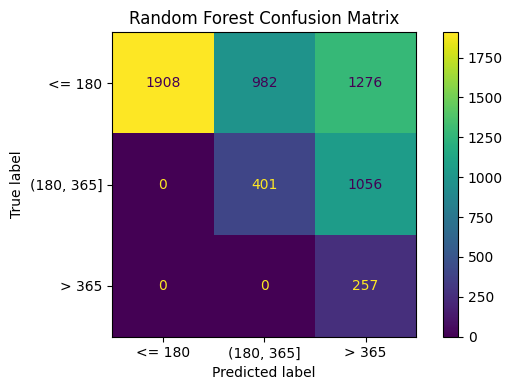

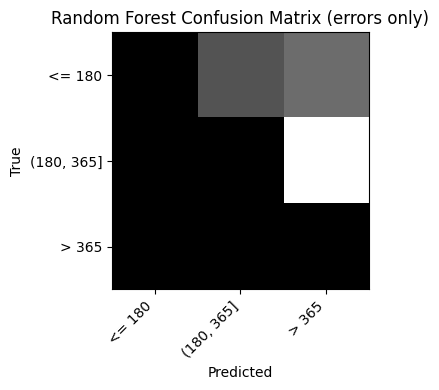

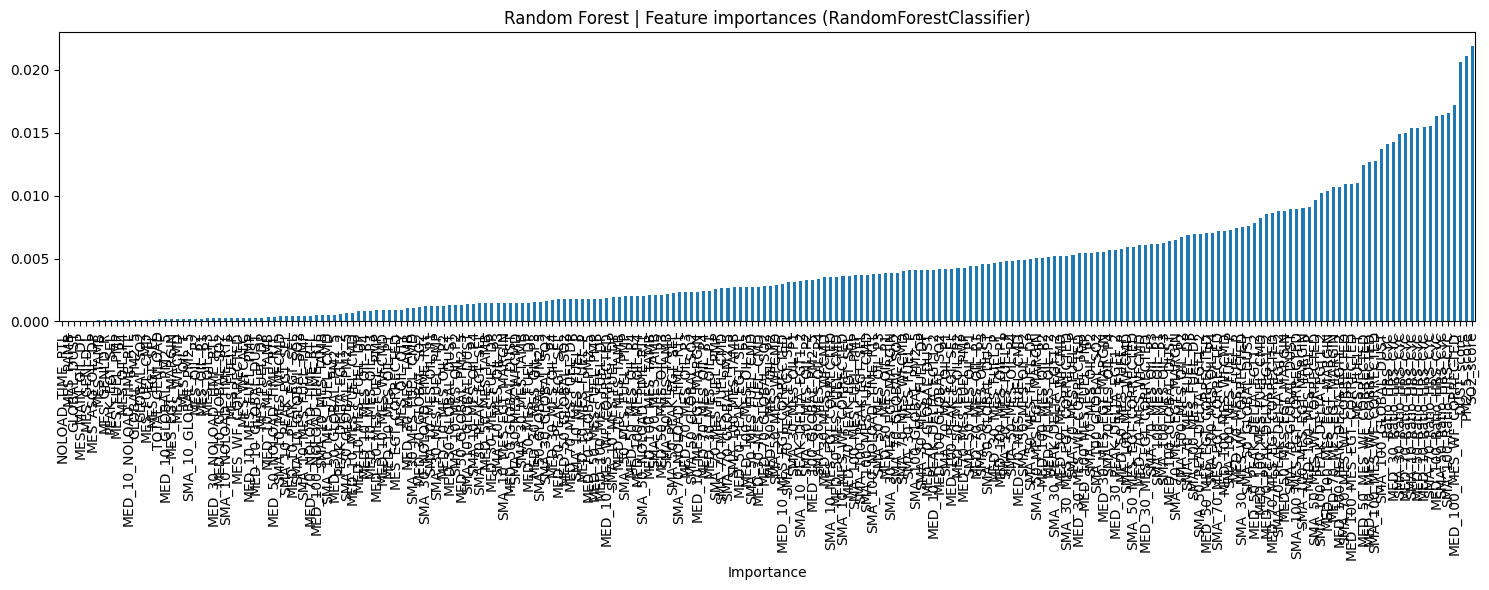


=== HGB ===
accuracy                  0.52
precision_macro           0.49
recall_macro              0.64
f1_score_macro            0.43
precision_weighted        0.80
recall_weighted           0.52
f1_weighted               0.60
precision_class_<= 180    1.00
recall_class_<= 180       0.55
f1_class_<= 180           0.71
dtype: float64

Classification Report:
              precision    recall  f1-score   support

      <= 180       1.00      0.55      0.71      4166
  (180, 365]       0.34      0.35      0.35      1457
       > 365       0.12      1.00      0.22       257

    accuracy                           0.52      5880
   macro avg       0.49      0.64      0.43      5880
weighted avg       0.80      0.52      0.60      5880



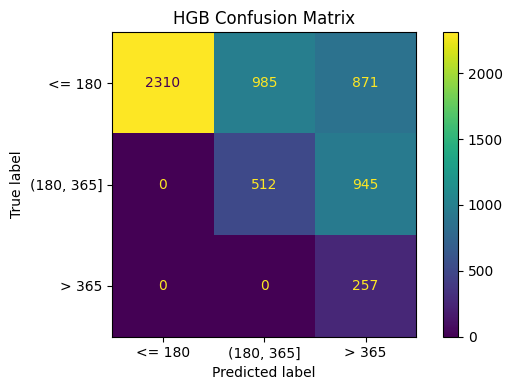

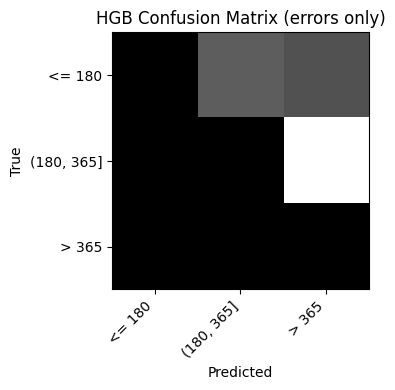


=== LightGBM ===
accuracy                  0.54
precision_macro           0.50
recall_macro              0.66
f1_score_macro            0.45
precision_weighted        0.80
recall_weighted           0.54
f1_weighted               0.61
precision_class_<= 180    1.00
recall_class_<= 180       0.56
f1_class_<= 180           0.72
dtype: float64

Classification Report:
              precision    recall  f1-score   support

      <= 180       1.00      0.56      0.72      4166
  (180, 365]       0.37      0.41      0.39      1457
       > 365       0.13      1.00      0.24       257

    accuracy                           0.54      5880
   macro avg       0.50      0.66      0.45      5880
weighted avg       0.80      0.54      0.61      5880



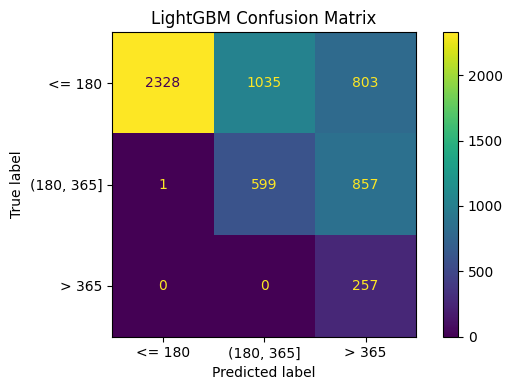

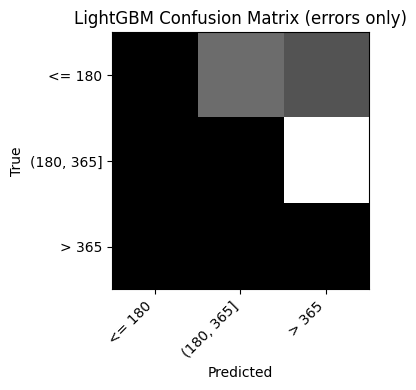

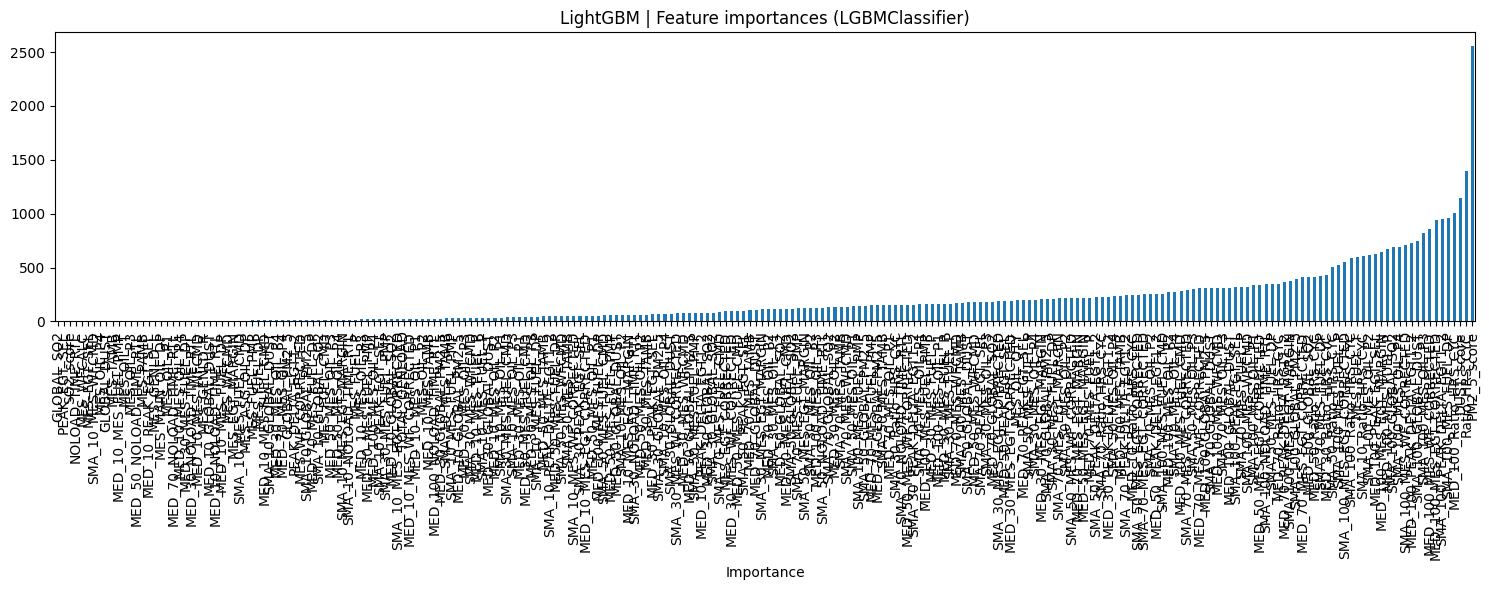


=== KNeighbors ===
accuracy                  0.31
precision_macro           0.42
recall_macro              0.50
f1_score_macro            0.27
precision_weighted        0.76
recall_weighted           0.31
f1_weighted               0.38
precision_class_<= 180    1.00
recall_class_<= 180       0.31
f1_class_<= 180           0.47
dtype: float64

Classification Report:
              precision    recall  f1-score   support

      <= 180       1.00      0.31      0.47      4166
  (180, 365]       0.19      0.19      0.19      1457
       > 365       0.08      1.00      0.15       257

    accuracy                           0.31      5880
   macro avg       0.42      0.50      0.27      5880
weighted avg       0.76      0.31      0.38      5880



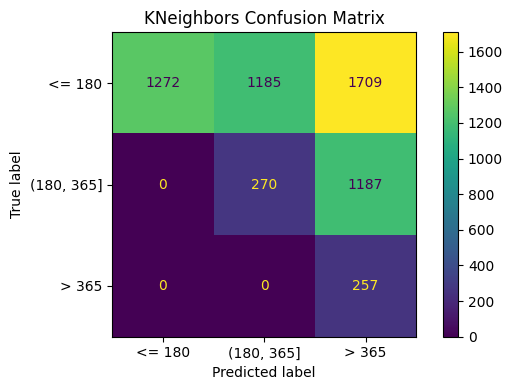

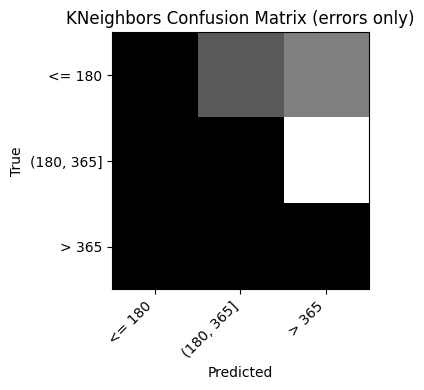


=== KNeighbors Radius ===
accuracy                  0.08
precision_macro           0.35
recall_macro              0.35
f1_score_macro            0.06
precision_weighted        0.71
recall_weighted           0.08
f1_weighted               0.06
precision_class_<= 180    1.00
recall_class_<= 180       0.04
f1_class_<= 180           0.08
dtype: float64

Classification Report:
              precision    recall  f1-score   support

      <= 180       1.00      0.04      0.08      4166
  (180, 365]       0.00      0.00      0.00      1457
       > 365       0.05      1.00      0.09       257

    accuracy                           0.07      5880
   macro avg       0.35      0.35      0.06      5880
weighted avg       0.71      0.07      0.06      5880



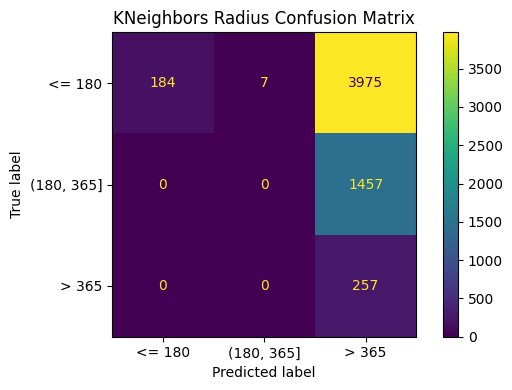

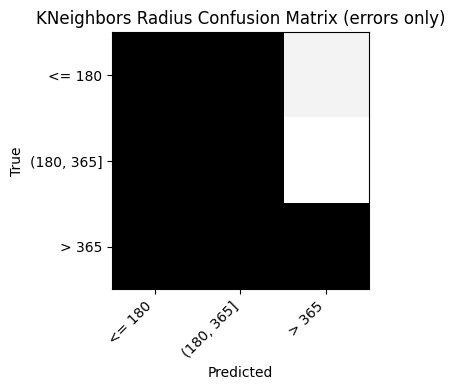


=== Neural Network Classifier ===
accuracy                  0.49
precision_macro           0.45
recall_macro              0.60
f1_score_macro            0.39
precision_weighted        0.76
recall_weighted           0.49
f1_weighted               0.57
precision_class_<= 180    0.97
recall_class_<= 180       0.55
f1_class_<= 180           0.70
dtype: float64

Classification Report:
              precision    recall  f1-score   support

      <= 180       0.97      0.55      0.70      4166
  (180, 365]       0.25      0.25      0.25      1457
       > 365       0.12      1.00      0.22       257

    accuracy                           0.49      5880
   macro avg       0.45      0.60      0.39      5880
weighted avg       0.76      0.49      0.57      5880



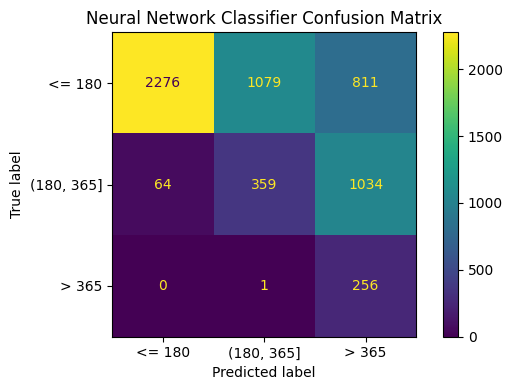

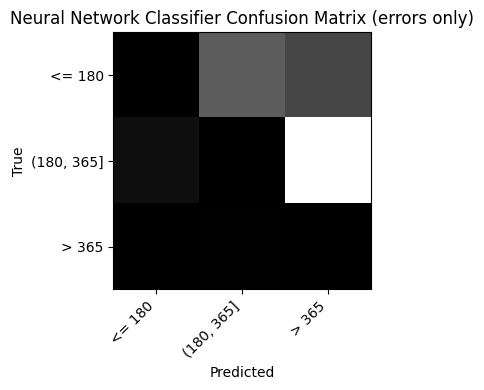

,accuracy,precision_macro,recall_macro,f1_score_macro,precision_weighted,recall_weighted,f1_weighted,precision_class_<= 180,recall_class_<= 180,f1_class_<= 180
LightGBM,0.541497,0.500073,0.656643,0.446956,0.804895,0.541497,0.614268,0.999571,0.558809,0.716859
HGB,0.523639,0.488664,0.635299,0.426884,0.798670,0.523639,0.600986,1.000000,0.554489,0.713403
Neural Network Classifier,0.491667,0.447992,0.596278,0.388241,0.756269,0.491667,0.566637,0.972650,0.546327,0.699662
Random Forest,0.436395,0.463072,0.577739,0.363750,0.784688,0.436395,0.522986,1.000000,0.457993,0.628252
KNeighbors,0.305952,0.422359,0.496880,0.267997,0.758047,0.305952,0.383989,1.000000,0.305329,0.467819
KNeighbors Radius,0.075000,0.348392,0.348056,0.057014,0.710478,0.075000,0.063716,1.000000,0.044167,0.084598


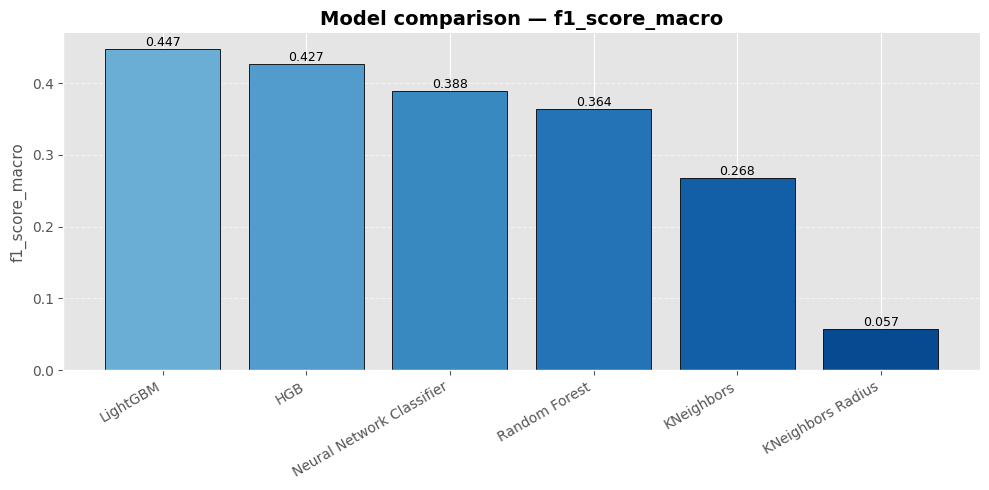

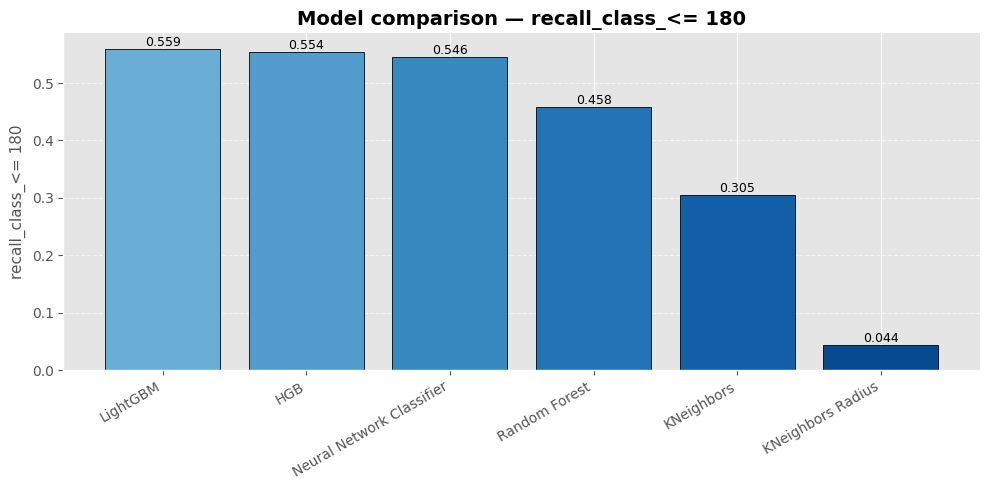

In [7]:
models={
    "Random Forest" : rf_classifier,
    "HGB":hgb_classifier,
    "LightGBM":lgbm_classifier,
    "KNeighbors":kneighbors_classifier,
    "KNeighbors Radius":kneighbors_radius_classifier,
    "Neural Network Classifier":rnn_mlp_classifier,
}

summary,fitted_models=ML_utils.benchmark_models(
    models=models,
    X_train=X_train,y_train=Y_train,
    X_test=X_test,y_test=Y_test,
    features=classification_features,
    mapping_categories=mapping_categories,
    critical_class=0,plot_each=True,plot_importance_rf=True
)

display(summary)

ML_utils.plot_model_comparison_bars(
    summary=summary,
    mapping_categories=mapping_categories,
)

## 9- Model Features Selection Optimization:
From the previous cells, we observed that LightGBM, HGB and Neural Network Classifier are the top 3 best models. From Section 6 of this notebook, the predictions are based on 234 features (`len(X_train.columns)=234`). In this section, we'll optimize the features selection ensuring an optimized score and avoiding data leakage impacting our models performances.

In [8]:
#### IMPORTANT : The execution of this cell may take several minutes
models={
        "HGB":hgb_classifier,
        "LightGBM":lgbm_classifier,
        "Neural Network Classifier":rnn_mlp_classifier}

summary_fs=ML_utils.benchmark_feature_subsets(
    models=models,
    X_train=X_train,Y_train=Y_train,
    X_test=X_test,Y_test=Y_test,
    mapping_categories=mapping_categories
)

Fetching different features: 100%|██████████| 24/24 [2:08:20<00:00, 320.86s/nb_features]


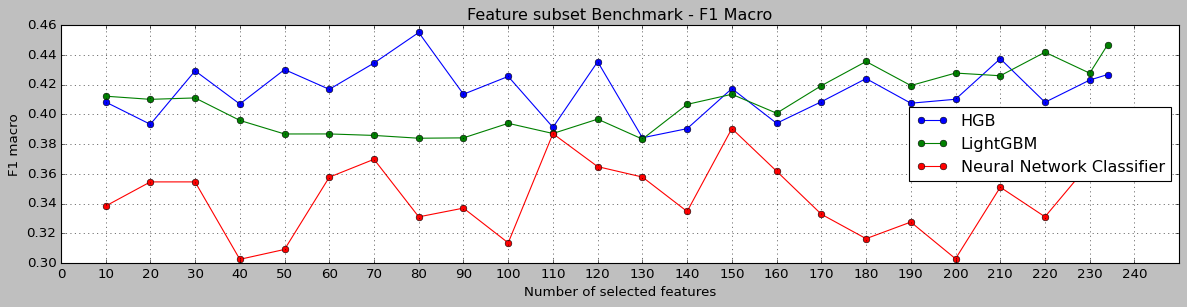

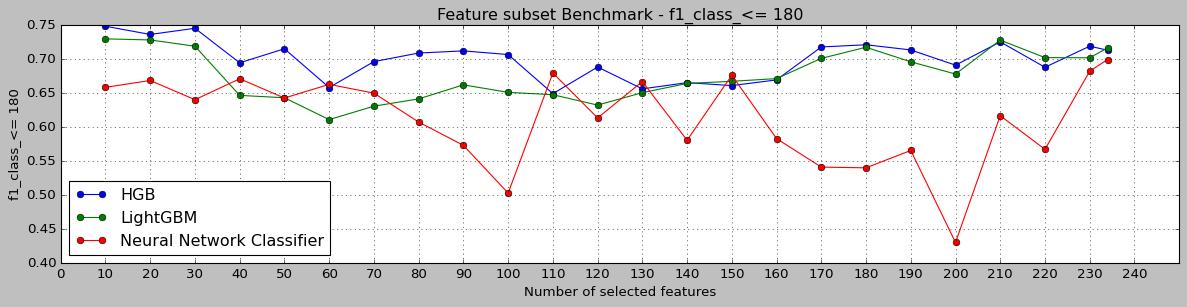

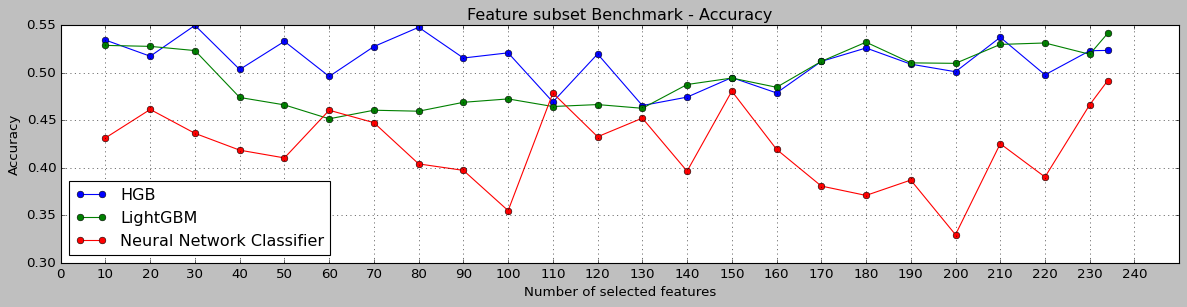

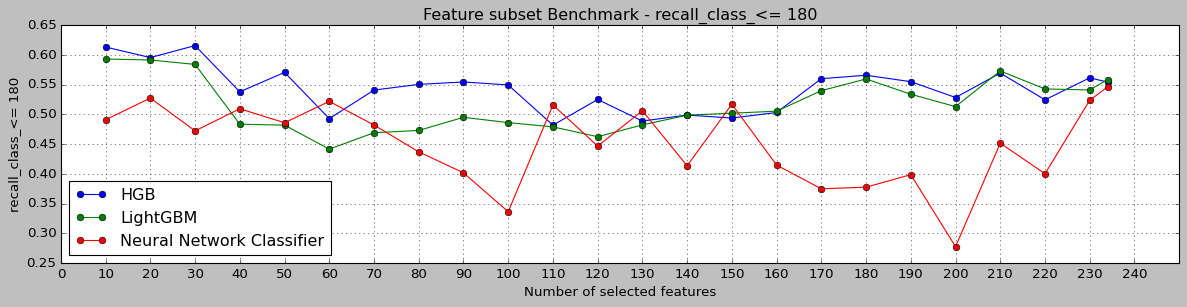

In [9]:
ML_utils.plot_feature_subset_benchmark(
    summary_fs=summary_fs,mapping_categories=mapping_categories
)

## 10- Ensemble Voting Classifier:
Ensemble Voting Classifier vs Single Model Approach


=== Random Forest ===
accuracy                  0.44
precision_macro           0.46
recall_macro              0.58
f1_score_macro            0.36
precision_weighted        0.78
recall_weighted           0.44
f1_weighted               0.52
precision_class_<= 180    1.00
recall_class_<= 180       0.46
f1_class_<= 180           0.63
dtype: float64

Classification Report:
              precision    recall  f1-score   support

      <= 180       1.00      0.46      0.63      4166
  (180, 365]       0.29      0.28      0.28      1457
       > 365       0.10      1.00      0.18       257

    accuracy                           0.44      5880
   macro avg       0.46      0.58      0.36      5880
weighted avg       0.78      0.44      0.52      5880



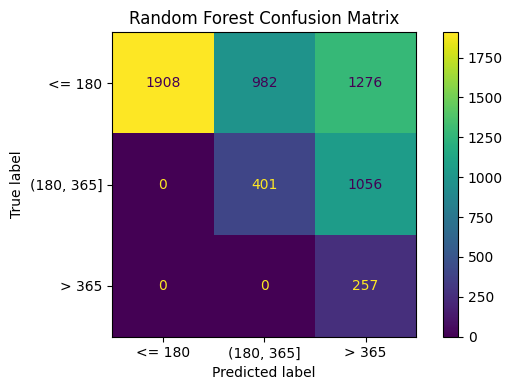

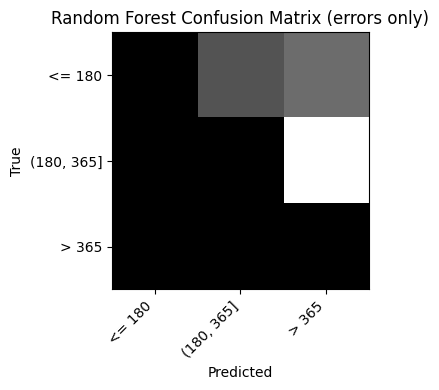

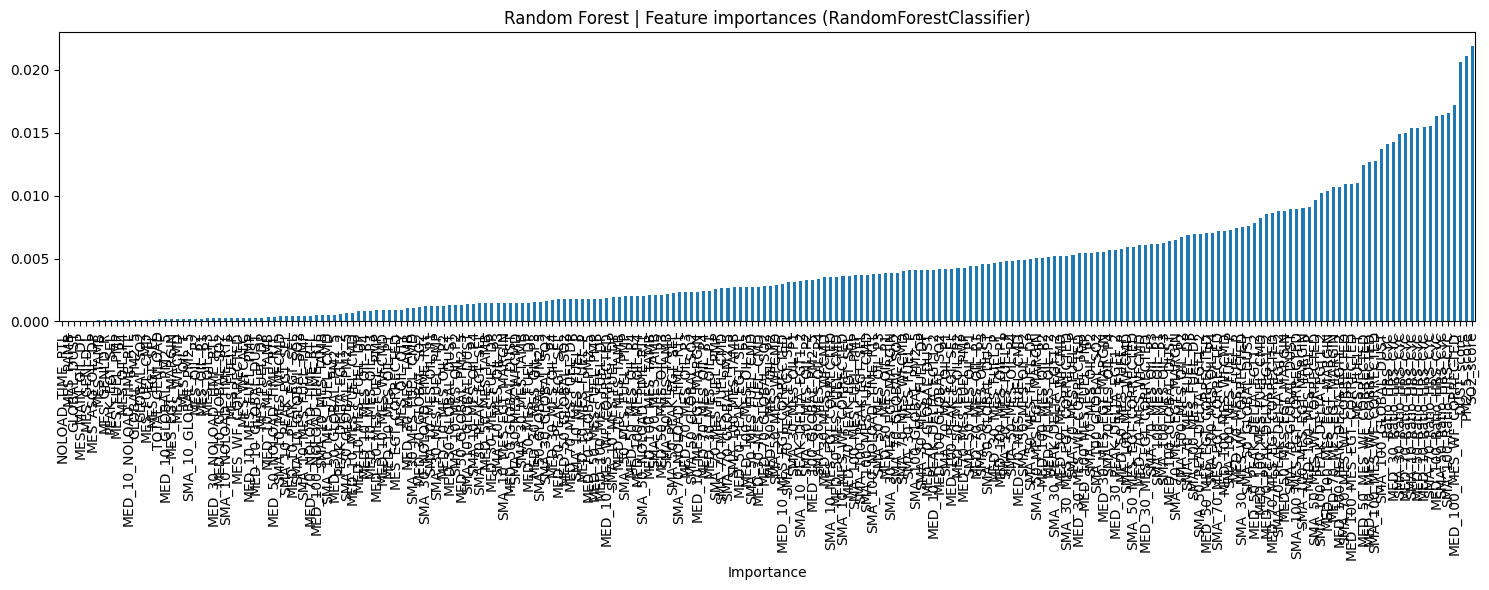


=== HGB ===
accuracy                  0.52
precision_macro           0.49
recall_macro              0.64
f1_score_macro            0.43
precision_weighted        0.80
recall_weighted           0.52
f1_weighted               0.60
precision_class_<= 180    1.00
recall_class_<= 180       0.55
f1_class_<= 180           0.71
dtype: float64

Classification Report:
              precision    recall  f1-score   support

      <= 180       1.00      0.55      0.71      4166
  (180, 365]       0.34      0.35      0.35      1457
       > 365       0.12      1.00      0.22       257

    accuracy                           0.52      5880
   macro avg       0.49      0.64      0.43      5880
weighted avg       0.80      0.52      0.60      5880



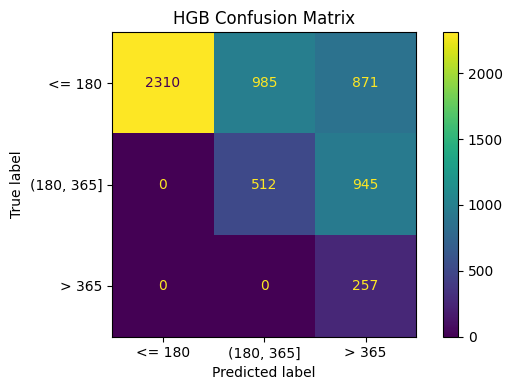

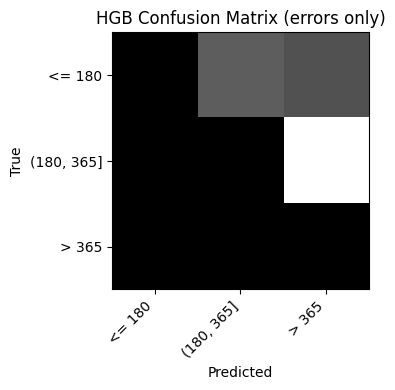


=== LightGBM ===
accuracy                  0.54
precision_macro           0.50
recall_macro              0.66
f1_score_macro            0.45
precision_weighted        0.80
recall_weighted           0.54
f1_weighted               0.61
precision_class_<= 180    1.00
recall_class_<= 180       0.56
f1_class_<= 180           0.72
dtype: float64

Classification Report:
              precision    recall  f1-score   support

      <= 180       1.00      0.56      0.72      4166
  (180, 365]       0.37      0.41      0.39      1457
       > 365       0.13      1.00      0.24       257

    accuracy                           0.54      5880
   macro avg       0.50      0.66      0.45      5880
weighted avg       0.80      0.54      0.61      5880



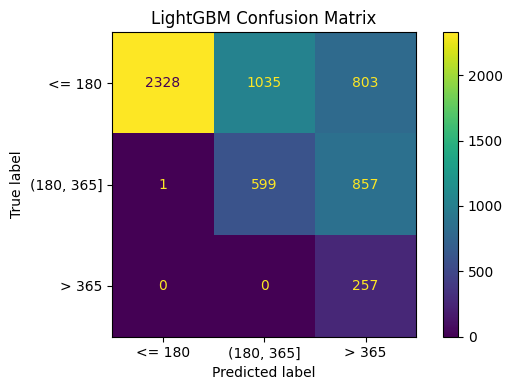

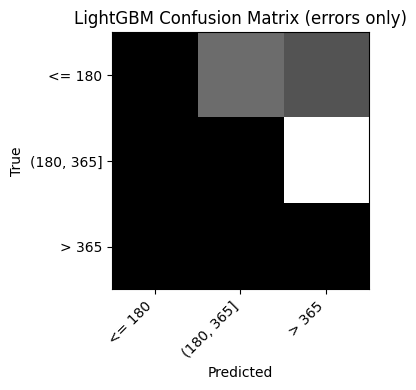

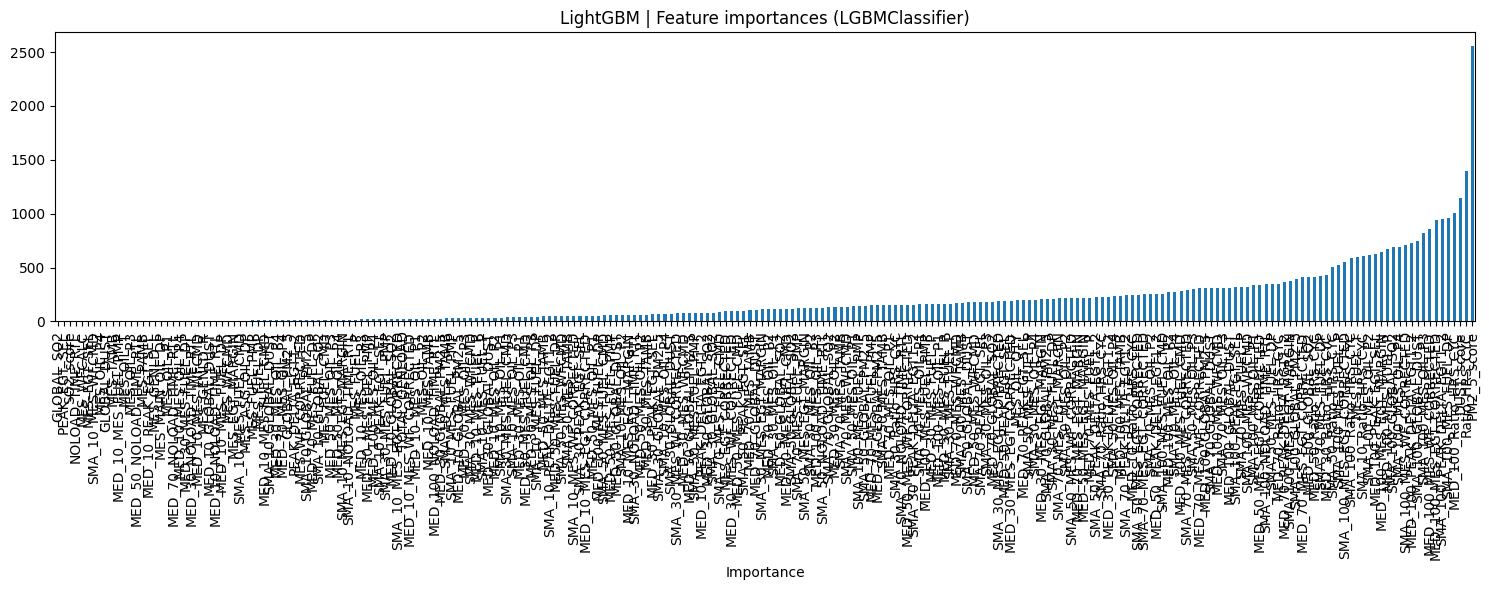


=== KNeighbors ===
accuracy                  0.31
precision_macro           0.42
recall_macro              0.50
f1_score_macro            0.27
precision_weighted        0.76
recall_weighted           0.31
f1_weighted               0.38
precision_class_<= 180    1.00
recall_class_<= 180       0.31
f1_class_<= 180           0.47
dtype: float64

Classification Report:
              precision    recall  f1-score   support

      <= 180       1.00      0.31      0.47      4166
  (180, 365]       0.19      0.19      0.19      1457
       > 365       0.08      1.00      0.15       257

    accuracy                           0.31      5880
   macro avg       0.42      0.50      0.27      5880
weighted avg       0.76      0.31      0.38      5880



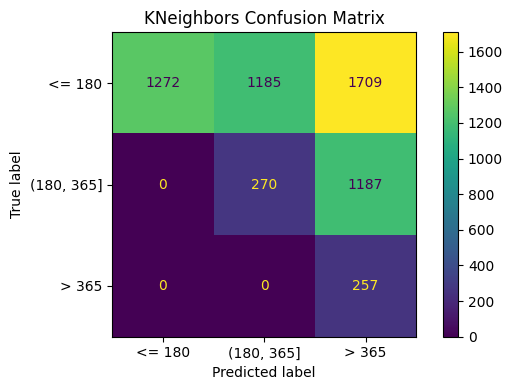

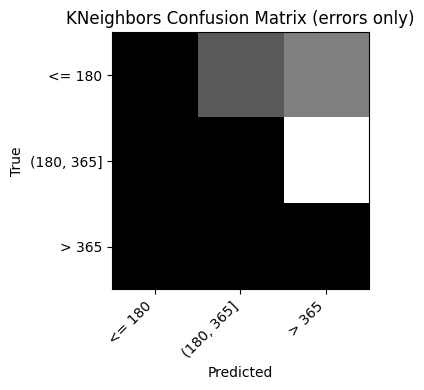


=== KNeighbors Radius ===
accuracy                  0.08
precision_macro           0.35
recall_macro              0.35
f1_score_macro            0.06
precision_weighted        0.71
recall_weighted           0.08
f1_weighted               0.06
precision_class_<= 180    1.00
recall_class_<= 180       0.04
f1_class_<= 180           0.08
dtype: float64

Classification Report:
              precision    recall  f1-score   support

      <= 180       1.00      0.04      0.08      4166
  (180, 365]       0.00      0.00      0.00      1457
       > 365       0.05      1.00      0.09       257

    accuracy                           0.07      5880
   macro avg       0.35      0.35      0.06      5880
weighted avg       0.71      0.07      0.06      5880



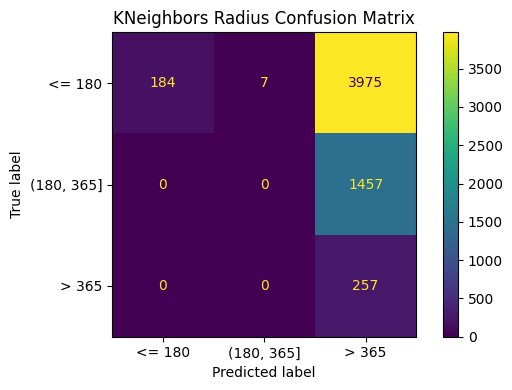

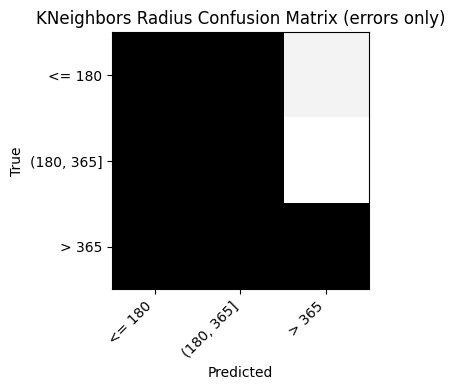


=== Neural Network Classifier ===
accuracy                  0.49
precision_macro           0.45
recall_macro              0.60
f1_score_macro            0.39
precision_weighted        0.76
recall_weighted           0.49
f1_weighted               0.57
precision_class_<= 180    0.97
recall_class_<= 180       0.55
f1_class_<= 180           0.70
dtype: float64

Classification Report:
              precision    recall  f1-score   support

      <= 180       0.97      0.55      0.70      4166
  (180, 365]       0.25      0.25      0.25      1457
       > 365       0.12      1.00      0.22       257

    accuracy                           0.49      5880
   macro avg       0.45      0.60      0.39      5880
weighted avg       0.76      0.49      0.57      5880



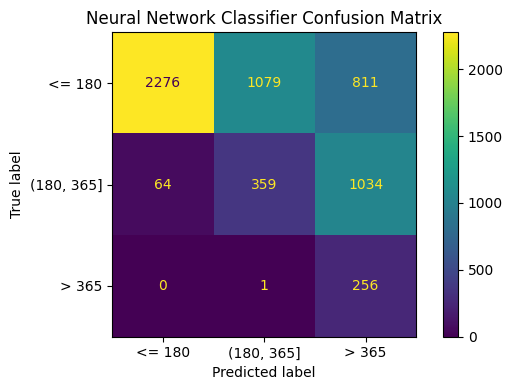

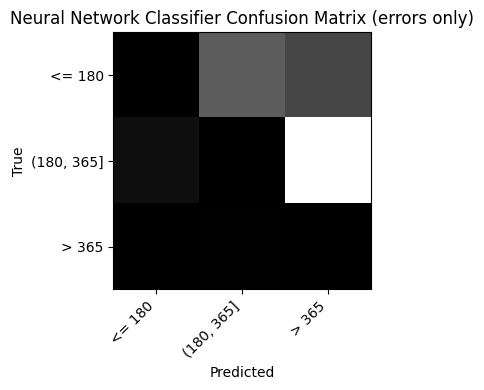


=== Ensemble Voting Classifier ===
accuracy                  0.54
precision_macro           0.48
recall_macro              0.63
f1_score_macro            0.43
precision_weighted        0.78
recall_weighted           0.54
f1_weighted               0.61
precision_class_<= 180    0.98
recall_class_<= 180       0.59
f1_class_<= 180           0.73
dtype: float64

Classification Report:
              precision    recall  f1-score   support

      <= 180       0.98      0.59      0.73      4166
  (180, 365]       0.32      0.31      0.32      1457
       > 365       0.13      1.00      0.23       257

    accuracy                           0.54      5880
   macro avg       0.48      0.63      0.43      5880
weighted avg       0.78      0.54      0.61      5880



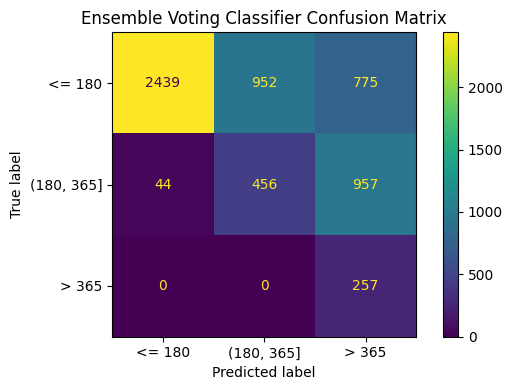

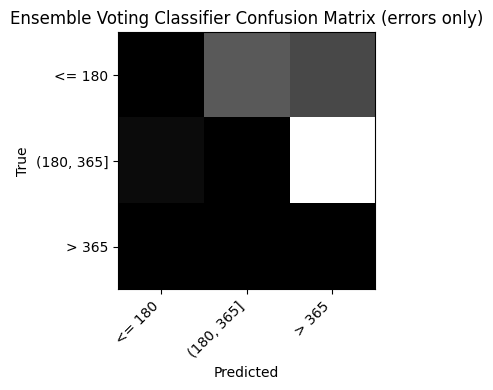

,accuracy,precision_macro,recall_macro,f1_score_macro,precision_weighted,recall_weighted,f1_weighted,precision_class_<= 180,recall_class_<= 180,f1_class_<= 180
Ensemble Voting Classifier,0.536054,0.478451,0.632809,0.426940,0.781846,0.536054,0.608669,0.982280,0.585454,0.733644
LightGBM,0.541497,0.500073,0.656643,0.446956,0.804895,0.541497,0.614268,0.999571,0.558809,0.716859
HGB,0.523639,0.488664,0.635299,0.426884,0.798670,0.523639,0.600986,1.000000,0.554489,0.713403
Neural Network Classifier,0.491667,0.447992,0.596278,0.388241,0.756269,0.491667,0.566637,0.972650,0.546327,0.699662
Random Forest,0.436395,0.463072,0.577739,0.363750,0.784688,0.436395,0.522986,1.000000,0.457993,0.628252
KNeighbors,0.305952,0.422359,0.496880,0.267997,0.758047,0.305952,0.383989,1.000000,0.305329,0.467819
KNeighbors Radius,0.075000,0.348392,0.348056,0.057014,0.710478,0.075000,0.063716,1.000000,0.044167,0.084598


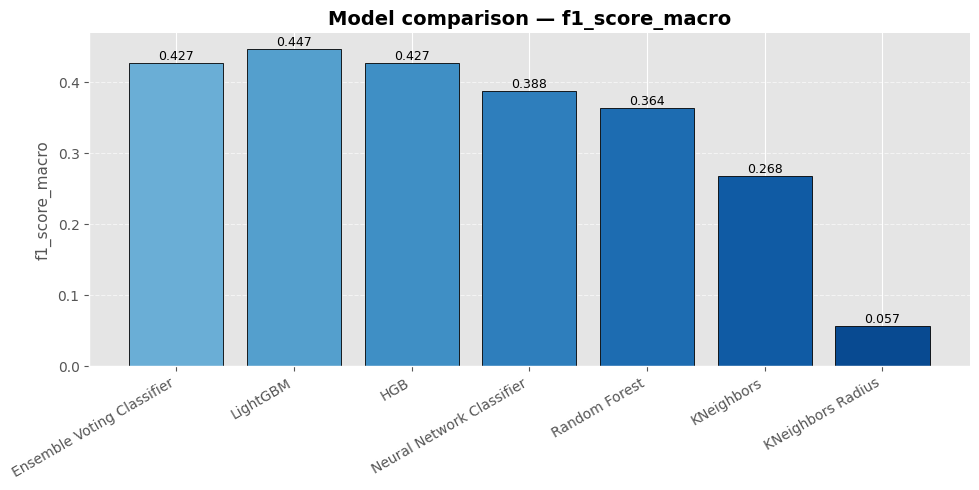

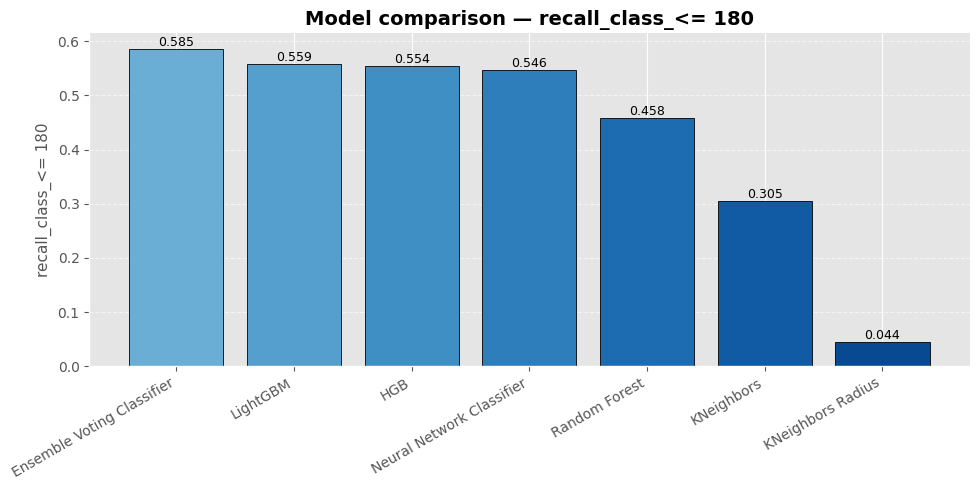

In [10]:
from sklearn.ensemble import VotingClassifier

voted_models={
    "HGB":hgb_classifier,
    "LightGBM":lgbm_classifier,
    "Neural Network Classifier":rnn_mlp_classifier,
}
voting_clf=VotingClassifier([(name,cl) for name,cl in voted_models.items()],voting='soft')

models={
    "Random Forest" : rf_classifier,
    "HGB":hgb_classifier,
    "LightGBM":lgbm_classifier,
    "KNeighbors":kneighbors_classifier,
    "KNeighbors Radius":kneighbors_radius_classifier,
    "Neural Network Classifier":rnn_mlp_classifier,
    "Ensemble Voting Classifier":voting_clf
}

summary,fitted_models=ML_utils.benchmark_models(
    models=models,
    X_train=X_train,y_train=Y_train,
    X_test=X_test,y_test=Y_test,
    features=classification_features,
    mapping_categories=mapping_categories,
    critical_class=0,plot_each=True,plot_importance_rf=True
)

display(summary)

ML_utils.plot_model_comparison_bars(
    summary=summary,
    mapping_categories=mapping_categories,
)

## 11- Ensemble Voting Classifier Evaluation (with ModelWrapper):

In [11]:
classification_features=list(k for k in config.Parameters_max_scale_for_normalization.keys() if k in train_dataset.columns)+ML_utils.get_rolling_column_names(rolling_configs=config.rolling_configs,rolling_values=config.ROLLING_VALUES)
classification_features.append("fwot_apusn")
X_test,Y_test,X_train,Y_train=ML_utils.time_series_split(
    train_dataset,
    min_date=None,
    split_date="2024-12-31T00:00:00",
    features=classification_features,
    target_col='Category')


===== Ensemble Voting Classifier -- t=0.03 =====
accuracy                  0.71
precision_macro           0.59
recall_macro              0.70
f1_score_macro            0.51
precision_weighted        0.84
recall_weighted           0.71
f1_weighted               0.73
precision_class_<= 180    0.94
recall_class_<= 180       0.86
f1_class_<= 180           1.00
roc_auc_macro             0.83
pr_auc_class_0            0.97
dtype: float64

CLassification Report:
              precision    recall  f1-score   support

      <= 180       0.94      0.86      0.90      4166
  (180, 365]       0.68      0.23      0.34      1457
       > 365       0.16      1.00      0.28       257

    accuracy                           0.71      5880
   macro avg       0.59      0.70      0.51      5880
weighted avg       0.84      0.71      0.73      5880



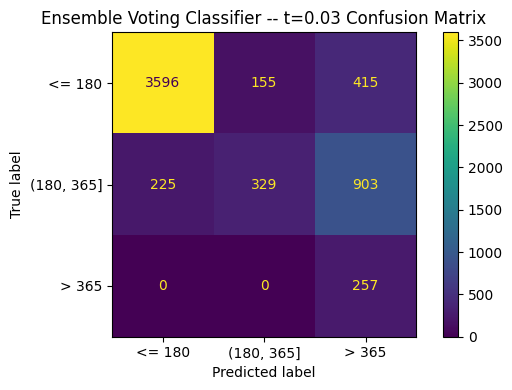

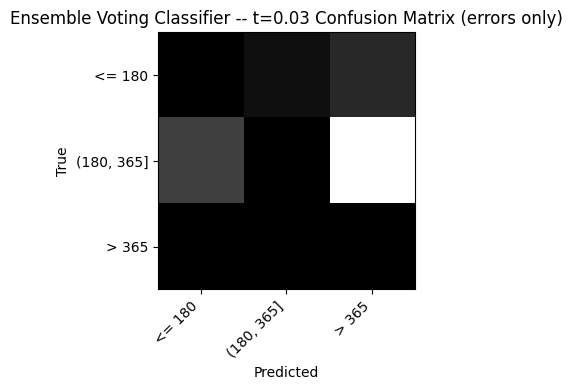

accuracy                  0.711224
precision_macro           0.594681
recall_macro              0.696328
f1_score_macro            0.506677
precision_weighted        0.842350
recall_weighted           0.711224
f1_weighted               0.734245
precision_class_<= 180    0.941115
recall_class_<= 180       0.863178
f1_class_<= 180           1.000000
roc_auc_macro             0.830586
pr_auc_class_0            0.969777
Name: Ensemble Voting Classifier -- t=0.03, dtype: float64

In [12]:
threshold=0.03
voting_clf.fit(X=X_train[[k for k in X_train.columns if k!='fwot_apusn']],y=Y_train)
model_wrapper_voting_clf=ModelWrapper(model=voting_clf,threshold=threshold,critical_class=0)
y_pred=model_wrapper_voting_clf.predict(X=X_test)
proba=model_wrapper_voting_clf.predict_proba(X=X_test)
ML_utils.evaluate_with_custom_predictions(
    name=f"Ensemble Voting Classifier -- t={threshold}",
    y_true=Y_test,y_pred=y_pred,proba=proba,
    model_classes=voting_clf.classes_,mapping_categories=mapping_categories,
    critical_class=0,plot=True,verbose=True
)

## 9- Ensemble Voting Classifier with ModelWrapper Optimization:
In this section, we will find out the best parameter for the modelwrapper such as threshold and window for Ensemble Voting Classifier.

In [ ]:
#### Threshold optimization
targets=list(k*0.01 for k in range(1,60,1))
df_threshold=pd.DataFrame()
for t in targets:
    hgb_model_wrapper=ModelWrapper(model=voting_clf,threshold=t,critical_class=0)
    y_pred=hgb_model_wrapper.predict(X=X_test,window=30)
    proba=hgb_model_wrapper.predict_proba(X=X_test,window=30)
    temp_df=pd.DataFrame(ML_utils.evaluate_with_custom_predictions(
        name=f"Voting_Classifier_wrapper_{round(t,2)}",
        y_true=Y_test,y_pred=y_pred,proba=proba,
        model_classes=voting_clf.classes_,mapping_categories=mapping_categories,
        critical_class=0,plot=False,verbose=False
    )).transpose()
    temp_df['Threshold']=t
    df_threshold=pd.concat([df_threshold,temp_df])
df_threshold

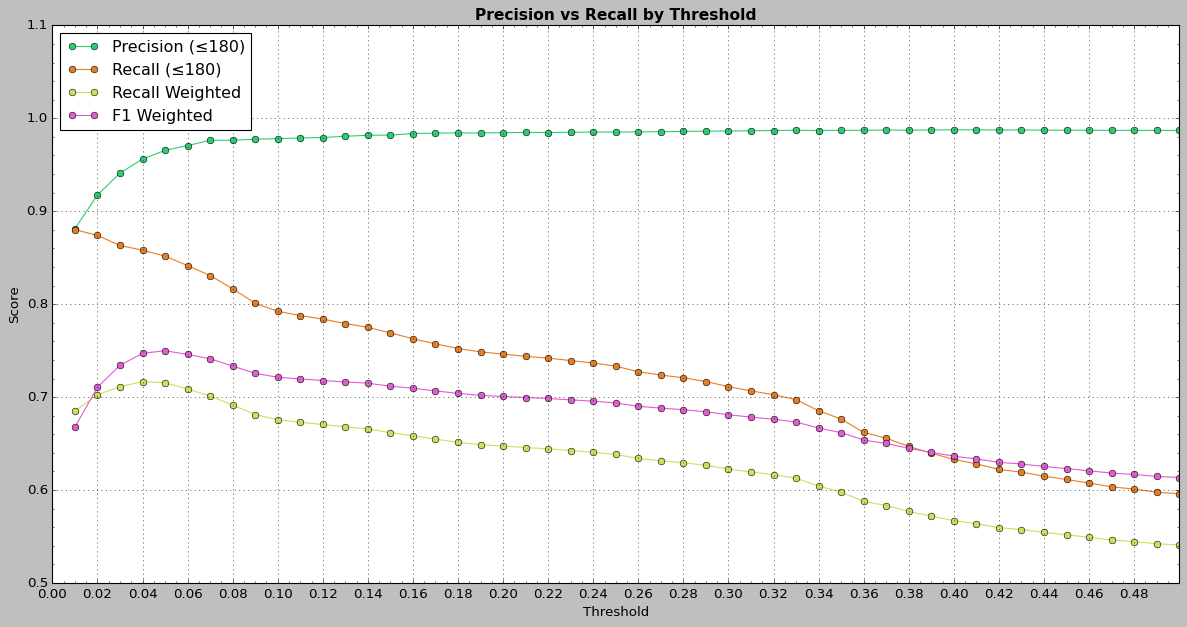

In [24]:
plt.style.use("classic")

fig, ax = plt.subplots(figsize=(15,8))

ax.plot(
    df_threshold["Threshold"],
    df_threshold["precision_class_<= 180"],
    label="Precision (≤180)",
    color="#2ecc71",
    marker="o",
)

ax.plot(
    df_threshold["Threshold"],
    df_threshold["recall_class_<= 180"],
    label="Recall (≤180)",
    color="#e67e22",
    marker="o",
)
ax.plot(
    df_threshold["Threshold"],
    df_threshold["recall_weighted"],
    label="Recall Weighted",
    color="#CDE05C",
    marker="o",
)
ax.plot(
    df_threshold["Threshold"],
    df_threshold["f1_weighted"],
    label="F1 Weighted",
    color="#E05CD5",
    marker="o",
)
ax.set_title("Precision vs Recall by Threshold", fontsize=14, fontweight="bold")
ax.set_xlabel("Threshold", fontsize=12)
ax.set_ylabel("Score", fontsize=12)

ax.set_ylim(0.5, 1.1)
ax.set_xlim(0,0.5)

start_x,end_x=ax.get_xlim()
start_y,end_y=ax.get_ylim()

ax.xaxis.set_ticks(np.arange(start_x,end_x,0.02))
ax.yaxis.set_ticks(np.arange(start_y,end_y,0.1))


ax.legend(loc='best',frameon=True)
ax.minorticks_on()
ax.grid()

plt.tight_layout()

In [ ]:
## Window optimization
targets_window=list(range(10,240,5))
df_window=pd.DataFrame()
for w in targets_window:
    hgb_model_wrapper=ModelWrapper(model=voting_clf,threshold=0.05,critical_class=0)
    y_pred=hgb_model_wrapper.predict(X=X_test,window=w)
    proba=hgb_model_wrapper.predict_proba(X=X_test,window=w)
    temp_df=pd.DataFrame(ML_utils.evaluate_with_custom_predictions(
        name=f"Voting_Classifier_wrapper_window={w}",
        y_true=Y_test,y_pred=y_pred,proba=proba,
        model_classes=voting_clf.classes_,mapping_categories=mapping_categories,
        critical_class=0,plot=False,verbose=False
    )).transpose()
    temp_df['window']=w
    df_window=pd.concat([df_window,temp_df])
df_window

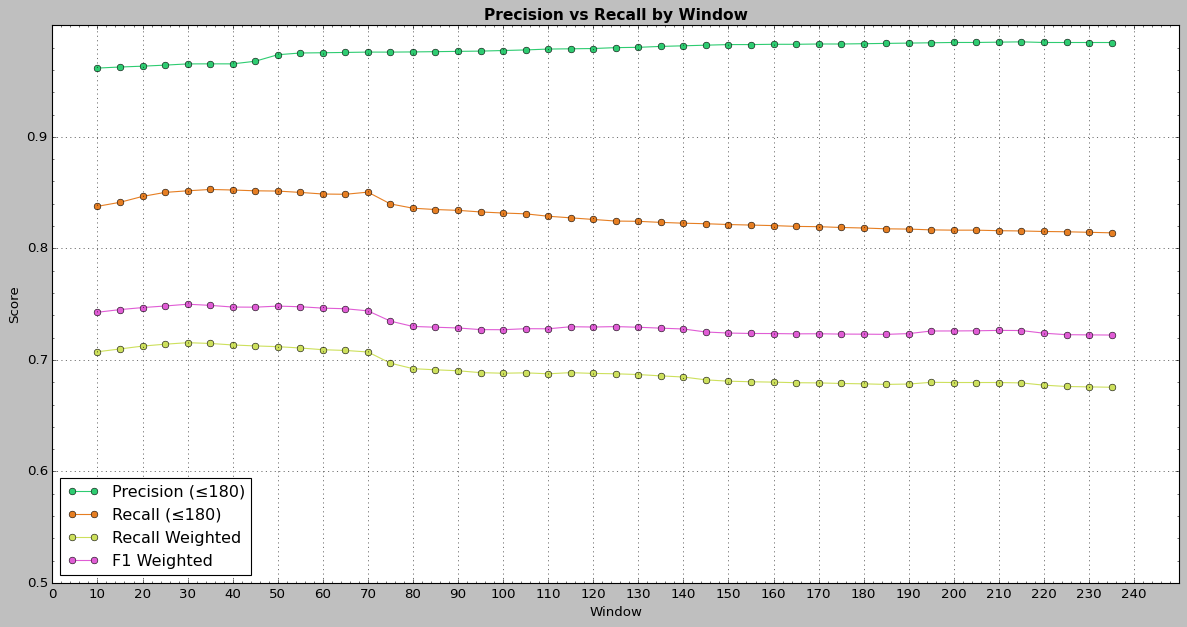

In [35]:
plt.style.use("classic")

fig, ax = plt.subplots(figsize=(15,8))

ax.plot(
    df_window["window"],
    df_window["precision_class_<= 180"],
    label="Precision (≤180)",
    color="#2ecc71",
    marker="o",
)

ax.plot(
    df_window["window"],
    df_window["recall_class_<= 180"],
    label="Recall (≤180)",
    color="#e67e22",
    marker="o",
)
ax.plot(
    df_window["window"],
    df_window["recall_weighted"],
    label="Recall Weighted",
    color="#CDE05C",
    marker="o",
)
ax.plot(
    df_window["window"],
    df_window["f1_weighted"],
    label="F1 Weighted",
    color="#E05CD5",
    marker="o",
)
ax.set_title("Precision vs Recall by Window", fontsize=14, fontweight="bold")
ax.set_xlabel("Window", fontsize=12)
ax.set_ylabel("Score", fontsize=12)

ax.set_ylim(0.5, 1)

start_x,end_x=ax.get_xlim()
start_y,end_y=ax.get_ylim()

ax.xaxis.set_ticks(np.arange(start_x,end_x,10))
ax.yaxis.set_ticks(np.arange(start_y,end_y,0.1))


ax.legend(loc='best',frameon=True)
ax.minorticks_on()
ax.grid()

plt.tight_layout()

## 10- Final Model To use for production:
we have a modelwrapper Ensemble Voting Classifier thresholded and windowed.


===== PrediCare_Ensemble_Voting_Classifier =====
accuracy                  0.71
precision_macro           0.59
recall_macro              0.70
f1_score_macro            0.51
precision_weighted        0.86
recall_weighted           0.71
f1_weighted               0.74
precision_class_<= 180    0.98
recall_class_<= 180       0.85
f1_class_<= 180           1.00
roc_auc_macro             0.84
pr_auc_class_0            0.97
dtype: float64

CLassification Report:
              precision    recall  f1-score   support

      <= 180       0.98      0.85      0.91      4166
  (180, 365]       0.66      0.25      0.36      1457
       > 365       0.15      1.00      0.26       257

    accuracy                           0.71      5880
   macro avg       0.59      0.70      0.51      5880
weighted avg       0.86      0.71      0.74      5880



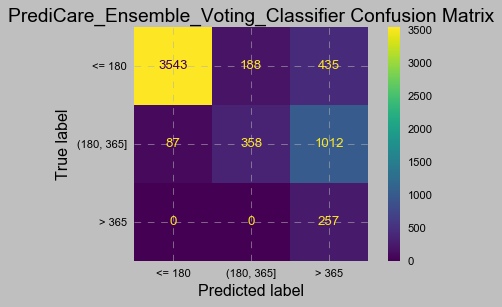

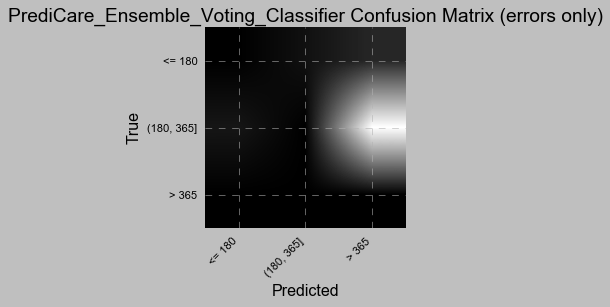

accuracy                  0.707143
precision_macro           0.594177
recall_macro              0.698722
f1_score_macro            0.509501
precision_weighted        0.860585
recall_weighted           0.707143
f1_weighted               0.744010
precision_class_<= 180    0.976033
recall_class_<= 180       0.850456
f1_class_<= 180           1.000000
roc_auc_macro             0.835714
pr_auc_class_0            0.971888
Name: PrediCare_Ensemble_Voting_Classifier, dtype: float64

In [ ]:
## FINAL EVALUATION
y_pred=ModelWrapper(model=voting_clf,threshold=0.05,critical_class=0).predict(X=X_test,window=70)
proba=ModelWrapper(model=voting_clf,threshold=0.05,critical_class=0).predict_proba(X=X_test,window=70)
ML_utils.evaluate_with_custom_predictions(
    name="PrediCare_Ensemble_Voting_Classifier",
    y_true=Y_test,y_pred=y_pred,proba=proba,
    model_classes=voting_clf.classes_,mapping_categories=mapping_categories,
    critical_class=0
)

In [43]:
model_package={
    "name":"Ensemble Voting Classifier",
    "model":voting_clf,
    "threshold":0.05,
    "window":70,
    "mapping_categories":mapping_categories,
    "critical_class":0
}
## Save the model for future use
with open("PrediCare_Ensemble_Voting_Classifier","wb") as f:
    pickle.dump(model_package,f)